# RUL Prediction: Hybrid Transformer Models
## LSTM-Transformer, GRU-Transformer, CNN-Transformer Architectures
**Owen's Implementation - Team Deep Learning Project**

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

SEED = 1234

def seed_everything(seed=1234):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
    
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Seed set to: {SEED}")

Using device: cuda
Seed set to: 1234


In [2]:
# If running in Colab, authenticate and mount Google Drive

from google.colab import auth
auth.authenticate_user()


## Part 1: Exploratory Data Analysis (EDA)

In [3]:
# Local paths to the processed NASA datasets
# train_df = pd.read_csv('../data/processed-nasa-data/train_processed_rul_only_fd001.csv')
# test_df = pd.read_csv('../data/processed-nasa-data/test_processed_rul_only_fd001.csv')

# Google Drive (if running in Colab)
DATA_PATH = '/content/drive/My Drive/deep_learning/project/'
train_df = pd.read_csv(f'{DATA_PATH}train_processed_rul_only_fd001.csv')
test_df = pd.read_csv(f'{DATA_PATH}test_processed_rul_only_fd001.csv')

print("="*80)
print("DATASET OVERVIEW - FD001")
print("="*80)

print(f"\n📊 Shape:")
print(f"  Training set: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
print(f"  Test set:     {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")

# print(f"\n🔧 Column Names & Types:")
# print(train_df.dtypes)

print(f"\n📈 RUL Statistics (TARGET VARIABLE):")
print(f"  Train RUL: Min={train_df['RUL'].min()}, Max={train_df['RUL'].max()}, Mean={train_df['RUL'].mean():.2f}, Std={train_df['RUL'].std():.2f}")
print(f"  Test RUL:  Min={test_df['RUL'].min()}, Max={test_df['RUL'].max()}, Mean={test_df['RUL'].mean():.2f}, Std={test_df['RUL'].std():.2f}")

print(f"\n🚀 Engine Analysis:")
n_train_engines = train_df['id'].nunique()
n_test_engines = test_df['id'].nunique()
print(f"  Training: {n_train_engines} engines")
print(f"  Test:     {n_test_engines} engines")

train_cycles = train_df.groupby('id')['cycle'].max()
test_cycles = test_df.groupby('id')['cycle'].max()
print(f"\n  Train cycles per engine: Min={train_cycles.min()}, Max={train_cycles.max()}, Mean={train_cycles.mean():.1f}")
print(f"  Test cycles per engine:  Min={test_cycles.min()}, Max={test_cycles.max()}, Mean={test_cycles.mean():.1f}")

print(f"\n🔍 Data Quality:")
print(f"  Missing values (train): {train_df.isnull().sum().sum()}")
print(f"  Missing values (test):  {test_df.isnull().sum().sum()}")


DATASET OVERVIEW - FD001

📊 Shape:
  Training set: 20,631 rows × 28 columns
  Test set:     13,096 rows × 28 columns

📈 RUL Statistics (TARGET VARIABLE):
  Train RUL: Min=0, Max=361, Mean=107.81, Std=68.88
  Test RUL:  Min=7, Max=340, Mean=141.24, Std=58.98

🚀 Engine Analysis:
  Training: 100 engines
  Test:     100 engines

  Train cycles per engine: Min=128, Max=362, Mean=206.3
  Test cycles per engine:  Min=31, Max=303, Mean=131.0

🔍 Data Quality:
  Missing values (train): 0
  Missing values (test):  0


### Simple EDA on the RUL dataset to understand the data distribution, feature importance, and potential correlations.

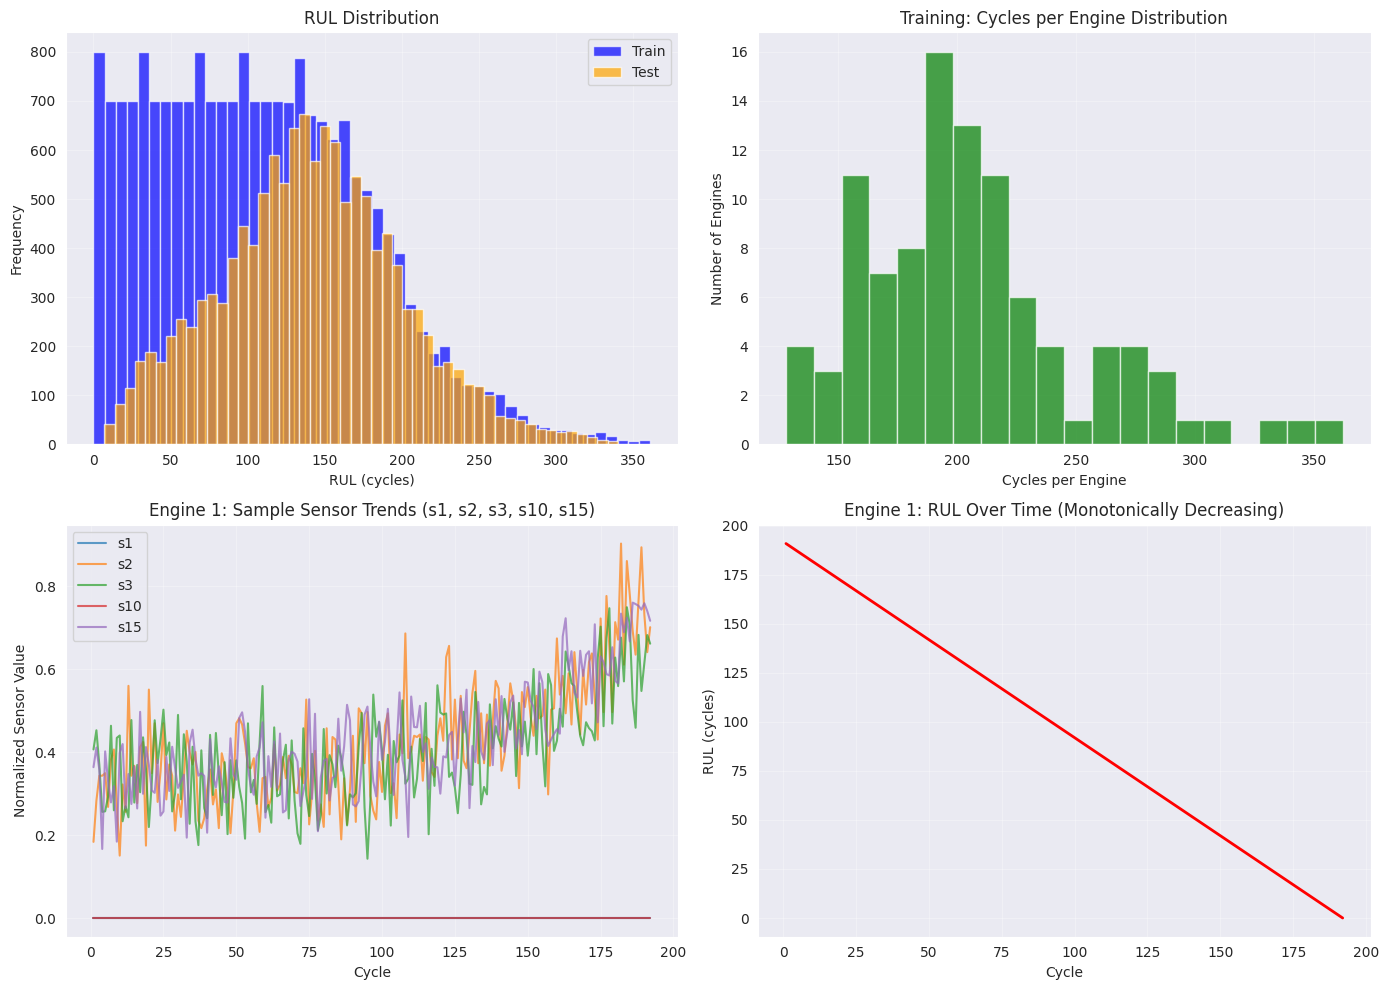

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RUL Distribution
''' 
- The RUL distribution in the training set is right-skewed, with most samples having a high RUL (indicating healthy engines) and fewer samples with low RUL (indicating engines close to failure).
- The test set has a similar distribution but with a slightly higher mean RUL, suggesting that the test engines may be generally healthier than those in the training set.
'''
axes[0, 0].hist(train_df['RUL'], bins=50, alpha=0.7, color='blue', label='Train')
axes[0, 0].hist(test_df['RUL'], bins=50, alpha=0.7, color='orange', label='Test')
axes[0, 0].set_xlabel('RUL (cycles)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('RUL Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Cycles per Engine
''' 
- The number of cycles per engine varies, with some engines running for over 200 cycles before failure.
- The distribution of cycles per engine is right-skewed, with many engines failing after fewer cycles and a long tail of engines that run for many cycles before failure.
'''
train_cycles_dist = train_df.groupby('id')['cycle'].max()
axes[0, 1].hist(train_cycles_dist, bins=20, color='green', alpha=0.7)
axes[0, 1].set_xlabel('Cycles per Engine')
axes[0, 1].set_ylabel('Number of Engines')
axes[0, 1].set_title('Training: Cycles per Engine Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Sample sensor trends (Engine 1)
''' 
- The sensor values for Engine 1 show varying patterns over time, with some sensors exhibiting more noise than others.
- There are noticeable trends in the sensor data that may be indicative of engine degradation. For example, sensor s1 shows a gradual increase in values as the engine approaches failure, while sensor s10 exhibits more erratic behavior.
'''
engine1_data = train_df[train_df['id'] == 1].sort_values('cycle')
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s1'], label='s1', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s2'], label='s2', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s3'], label='s3', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s10'], label='s10', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s15'], label='s15', alpha=0.7)
axes[1, 0].set_xlabel('Cycle')
axes[1, 0].set_ylabel('Normalized Sensor Value')
axes[1, 0].set_title('Engine 1: Sample Sensor Trends (s1, s2, s3, s10, s15)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. RUL Decay Pattern (Engine 1)
axes[1, 1].plot(engine1_data['cycle'], engine1_data['RUL'], color='red', linewidth=2)
axes[1, 1].set_xlabel('Cycle')
axes[1, 1].set_ylabel('RUL (cycles)')
axes[1, 1].set_title('Engine 1: RUL Over Time (Monotonically Decreasing)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2: Data Preparation & Sequence Creation

**Why do we need to create sequences for RUL prediction?**
- RUL prediction is a time-series forecasting problem where we want to predict the remaining useful life of a machine based on its historical sensor readings.
- Thus, we **cannot treat each data point independently or randomly shuffle the data,** as we would in a typical supervised learning problem.
- Creating sequences allows us to capture temporal dependencies and patterns in the data, which are crucial for accurate RUL prediction.
- By feeding sequences of sensor readings into our models, we can learn how the machine's condition evolves over time and make more informed predictions about its future state.
- In the next steps, we will preprocess the data, create sequences of sensor readings, and prepare the datasets for training our hybrid transformer models.

In [5]:
SEQUENCE_LENGTH = 50
BATCH_SIZE = 64
TRAIN_TEST_SPLIT = 0.8  # 80% of training data for training, 20% for validation

# Feature selection 
sensor_cols = [col for col in train_df.columns if col[0] == 's' and col[1:].isdigit()]
feature_cols = sensor_cols
num_features = len(feature_cols)

print(f"Input Sequence Length: {SEQUENCE_LENGTH}")
print(f"Number of Features: {num_features}")
print(f"Feature Columns: {feature_cols}")

class RULDataset(Dataset):
    def __init__(self, df, sequence_length=30, feature_cols=None):
        """
        Args:
            df: DataFrame with columns: id, cycle, and feature_cols, RUL
            sequence_length: Length of input sequences
            feature_cols: List of feature column names
        """
        self.sequence_length = sequence_length
        self.feature_cols = feature_cols or []
        self.sequences = []
        self.labels = []
        
        # Create sequences per engine
        for engine_id in df['id'].unique():
            engine_data = df[df['id'] == engine_id].sort_values('cycle').reset_index(drop=True)
            features = engine_data[self.feature_cols].values
            rul = engine_data['RUL'].values
            
            # Create overlapping sequences
            for i in range(len(engine_data) - sequence_length):
                self.sequences.append(features[i:i+sequence_length])
                self.labels.append(rul[i+sequence_length])                         ### Define label as the RUL at the end of the sequence (i+sequence_length)

        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.float32)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):         ### Return X and y as tensors
        return torch.tensor(self.sequences[idx]), torch.tensor(self.labels[idx])

train_dataset = RULDataset(train_df, SEQUENCE_LENGTH, feature_cols)
test_dataset = RULDataset(test_df, SEQUENCE_LENGTH, feature_cols)

# Split training set into train/validation
train_size = int(TRAIN_TEST_SPLIT * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(
    train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, 
                        batch_size=BATCH_SIZE,
                        shuffle=True, 
                        num_workers=0, 
                        worker_init_fn=seed_worker)
val_loader = DataLoader(val_dataset, 
                        batch_size=BATCH_SIZE, 
                        shuffle=False, 
                        num_workers=0, 
                        worker_init_fn=seed_worker)
test_loader = DataLoader(test_dataset, 
                        batch_size=BATCH_SIZE, 
                        shuffle=False, 
                        num_workers=0, 
                        worker_init_fn=seed_worker)

print(f"\n✅ Dataset Creation Complete:")
print(f"  Training sequences: {len(train_dataset)}")
print(f"  Validation sequences: {len(val_dataset)}")
print(f"  Test sequences: {len(test_dataset)}")
print(f"  Each sequence shape: ({SEQUENCE_LENGTH}, {num_features})")

Input Sequence Length: 50
Number of Features: 21
Feature Columns: ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']

✅ Dataset Creation Complete:
  Training sequences: 12504
  Validation sequences: 3127
  Test sequences: 8162
  Each sequence shape: (50, 21)


## Part 3: Model Architectures

### Overview: Hybrid Transformer Models

**Concept:** Combine RNN/CNN feature extraction with Transformer attention for improved sequence modeling.

Architecture variants:
1. **LSTM-Transformer:** LSTM feature extraction → Transformer refinement
2. **GRU-Transformer:** GRU feature extraction → Transformer refinement  
3. **CNN-Transformer:** 1D CNN feature extraction → Transformer refinement

Reference:
- [LSTM-Transformer Paper](https://arxiv.org/abs/2002.04745)
- [GRU-Transformer Paper](https://arxiv.org/abs/2103.00020)
- [CNN-Transformer Paper](https://arxiv.org/abs/2106.00020)
- [PyTorch Transformer Documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html)
- [Attention Is All You Need Paper](https://arxiv.org/abs/1706.03762)

In [6]:
# ============ BASE COMPONENTS ============

class TransformerEncoder(nn.Module):
    """Standard Transformer Encoder Block
    
    Arguments:
    - d_model: Dimension of the input and output features
    - nhead: Number of attention heads
    - dim_feedforward: Dimension of the feed-forward network
    - dropout: Dropout rate

    Architecture:
    1. Multi-head self-attention
    2. Add & Norm
    3. Position-wise feed-forward network
    4. Add & Norm
    """
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        # Self-attention
        attn_out, _ = self.attention(x, x, x)
        x = self.norm1(x + self.dropout(attn_out))
        
        # Feed-forward
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        
        return x

# ============ MODEL 1: LSTM-Transformer ============

class LSTMTransformer(nn.Module):
    """
    LSTM-Transformer Model
    
    Architecture:
    1. Input: (batch, seq_len, num_features)
    2. LSTM layers for temporal feature extraction
    3. Transformer encoder for attention-based modeling
    4. Global average pooling
    5. FC layers for RUL prediction
    """
    
    def __init__(self, num_features, lstm_hidden=64, num_lstm_layers=2, 
                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super().__init__()
        
        self.num_features = num_features
        self.lstm_hidden = lstm_hidden
        self.d_model = d_model
        
        # LSTM Feature Extraction
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=lstm_hidden,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0,
            bidirectional=True
        )
        
        lstm_output_dim = lstm_hidden * 2  # Bidirectional
        
        self.projection = nn.Linear(lstm_output_dim, d_model)
        self.transformer_layers = nn.ModuleList([           # Transformer Encoder Stack
            TransformerEncoder(d_model, nhead, d_model*4, dropout)
            for _ in range(num_transformer_layers)
        ])
        self.fc1 = nn.Linear(d_model, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # x: (batch, seq_len, num_features)
        lstm_out, _ = self.lstm(x)  # (batch, seq_len, lstm_hidden*2)
        x = self.projection(lstm_out)  # (batch, seq_len, d_model)
        for transformer in self.transformer_layers:
            x = transformer(x)
        
        x = x.mean(dim=1)  # (batch, d_model)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # (batch, 1)
        
        return x.squeeze(1)

# ============ MODEL 2: GRU-Transformer ============

class GRUTransformer(nn.Module):
    """
    GRU-Transformer Model
    
    Architecture:
    1. Input: (batch, seq_len, num_features)
    2. GRU layers for temporal feature extraction
    3. Transformer encoder for attention-based modeling
    4. Global average pooling
    5. FC layers for RUL prediction
    """
    
    def __init__(self, num_features, gru_hidden=64, num_gru_layers=2, 
                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super().__init__()
        
        self.num_features = num_features
        self.gru_hidden = gru_hidden
        self.d_model = d_model
        
        # GRU Feature Extraction
        self.gru = nn.GRU(
            input_size=num_features,
            hidden_size=gru_hidden,
            num_layers=num_gru_layers,
            batch_first=True,
            dropout=dropout if num_gru_layers > 1 else 0,
            bidirectional=True
        )
        
        gru_output_dim = gru_hidden * 2  # Bidirectional
        
        self.projection = nn.Linear(gru_output_dim, d_model)
        self.transformer_layers = nn.ModuleList([
            TransformerEncoder(d_model, nhead, d_model*4, dropout)
            for _ in range(num_transformer_layers)
        ])
        self.fc1 = nn.Linear(d_model, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # x: (batch, seq_len, num_features)
        
        gru_out, _ = self.gru(x)  # (batch, seq_len, gru_hidden*2)
        x = self.projection(gru_out)  # (batch, seq_len, d_model)
        
        # Transformer encoder
        for transformer in self.transformer_layers:
            x = transformer(x)
        
        x = x.mean(dim=1)  # (batch, d_model)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # (batch, 1)
        
        return x.squeeze(1)

# ============ MODEL 3: CNN-Transformer ============

class CNNTransformer(nn.Module):
    """
    CNN-Transformer Model
    
    Architecture:
    1. Input: (batch, seq_len, num_features)
    2. 1D CNN layers for local feature extraction
    3. Transformer encoder for global attention
    4. Global average pooling
    5. FC layers for RUL prediction
    """
    
    def __init__(self, num_features, num_filters=32, kernel_size=3,
                 d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super().__init__()
        
        self.num_features = num_features
        self.num_filters = num_filters
        self.d_model = d_model
        
        # 1D CNN Feature Extraction
        self.conv1 = nn.Conv1d(num_features, num_filters, kernel_size=kernel_size, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(num_filters)
        self.conv2 = nn.Conv1d(num_filters, num_filters*2, kernel_size=kernel_size, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(num_filters*2)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(None)  # No pooling, keep sequence length
        
        cnn_output_dim = num_filters * 2
        
        self.projection = nn.Linear(cnn_output_dim, d_model)
        self.transformer_layers = nn.ModuleList([
            TransformerEncoder(d_model, nhead, d_model*4, dropout)
            for _ in range(num_transformer_layers)
        ])
        self.fc1 = nn.Linear(d_model, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x: (batch, seq_len, num_features)
        x = x.transpose(1, 2)  # (batch, num_features, seq_len)
        
        # CNN blocks
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))  # (batch, num_filters*2, seq_len)
        x = x.transpose(1, 2)  # (batch, seq_len, num_filters*2)
        x = self.projection(x)  # (batch, seq_len, d_model)
        
        # Transformer encoder
        for transformer in self.transformer_layers:
            x = transformer(x)
        x = x.mean(dim=1)  # (batch, d_model)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # (batch, 1)
        
        return x.squeeze(1)


## Part 4: Training Framework & Utilities

In [7]:
class EarlyStoppingCallback:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=10, delta=0.001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_val_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_val_loss is None:
            self.best_val_loss = val_loss
        elif val_loss > self.best_val_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_val_loss = val_loss
            self.counter = 0
        
        return self.early_stop

class ModelTrainer:
    """Training framework for RUL prediction models"""
    
    def __init__(self, model, device, model_name='Model'):
        self.model = model.to(device)
        self.device = device
        self.model_name = model_name
        self.history = {'train_loss': [], 'val_loss': [], 'val_mae': [], 'val_rmse': []}
    
    def train_epoch(self, dataloader, optimizer, loss_fn):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
            
            # Forward pass
            predictions = self.model(X_batch)
            loss = loss_fn(predictions, y_batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        return total_loss / len(dataloader)
    
    def validate(self, dataloader, loss_fn):
        """Validate on validation set"""
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for X_batch, y_batch in dataloader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                
                predictions = self.model(X_batch)
                loss = loss_fn(predictions, y_batch)
                
                total_loss += loss.item()
                all_preds.extend(predictions.cpu().numpy())
                all_targets.extend(y_batch.cpu().numpy())
        
        avg_loss = total_loss / len(dataloader)
        mae = mean_absolute_error(all_targets, all_preds)
        rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
        
        return avg_loss, mae, rmse
    
    def train(self, train_loader, val_loader, epochs=50, lr=0.001, early_stopping_patience=10):
        """Full training loop"""
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()
        early_stopping = EarlyStoppingCallback(patience=early_stopping_patience)
        
        print(f"\n{'='*80}")
        print(f"Training {self.model_name}")
        print(f"{'='*80}")
        print(f"{'Epoch':<8} {'Train Loss':<15} {'Val Loss':<15} {'Val MAE':<12} {'Val RMSE':<12}")
        print(f"{'-'*80}")
        
        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader, optimizer, loss_fn)
            val_loss, val_mae, val_rmse = self.validate(val_loader, loss_fn)
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_mae'].append(val_mae)
            self.history['val_rmse'].append(val_rmse)
            
            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"{epoch+1:<8} {train_loss:<15.6f} {val_loss:<15.6f} {val_mae:<12.4f} {val_rmse:<12.4f}")
            
            if early_stopping(val_loss):
                print(f"\n⏹️  Early stopping at epoch {epoch+1}")
                break
        
        print(f"{'='*80}\n")
        return self.history
    
    def plot_history(self):
        """Plot training history"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # Loss
        axes[0].plot(self.history['train_loss'], label='Train Loss', alpha=0.7)
        axes[0].plot(self.history['val_loss'], label='Val Loss', alpha=0.7)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss (MSE)')
        axes[0].set_title(f'{self.model_name} - Training Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # MAE
        axes[1].plot(self.history['val_mae'], color='green', label='Val MAE', alpha=0.7)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('MAE (cycles)')
        axes[1].set_title(f'{self.model_name} - Validation MAE')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # RMSE
        axes[2].plot(self.history['val_rmse'], color='red', label='Val RMSE', alpha=0.7)
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('RMSE (cycles)')
        axes[2].set_title(f'{self.model_name} - Validation RMSE')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

## Part 5: Model Training & Evaluation

### Training all three hybrid transformer models on FD001 dataset


TRAINING ALL THREE HYBRID TRANSFORMER MODELS


****************************************************************************************************
Training: LSTM-Transformer
****************************************************************************************************

Training LSTM-Transformer
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        6109.731104     1993.221924     32.2088      44.6369     
5        741.554121      593.383043      16.6136      24.3654     
10       651.776846      526.017333      15.2926      22.9404     
15       619.745554      498.326536      14.6802      22.3295     
20       582.312573      540.799599      15.3464      23.2576     
25       550.415809      421.031744      13.7930      20.5189     
30       523.552264      476.462301      15.2426      21.8268     
35       480.450094      399.516918      13.9011      19.9870     
40       458

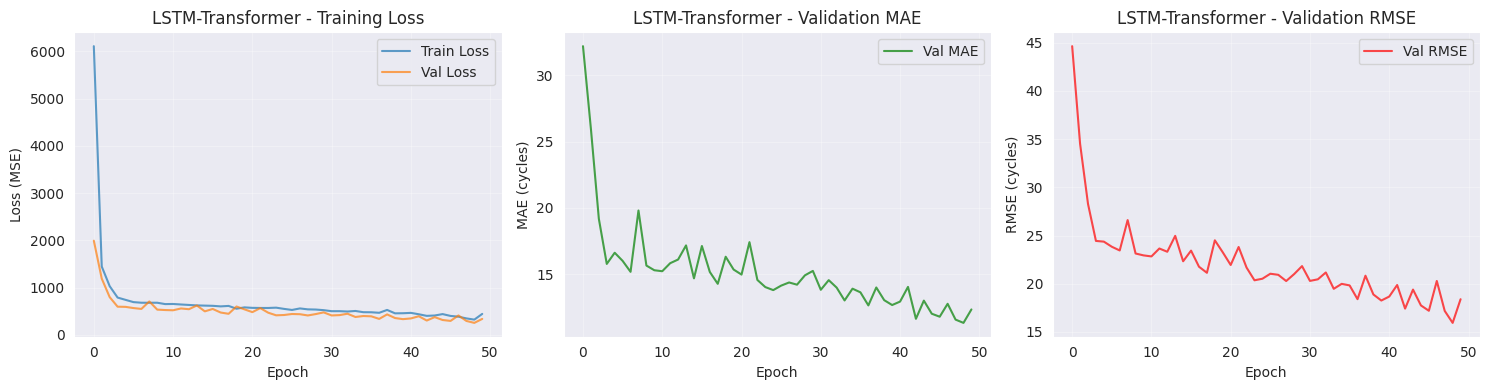


****************************************************************************************************
Training: GRU-Transformer
****************************************************************************************************

Training GRU-Transformer
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        7886.348779     3762.300285     47.3317      61.3255     
5        740.753055      598.957645      16.6514      24.4777     
10       671.227100      513.510548      14.7279      22.6668     
15       715.270010      633.436122      15.6288      25.1800     
20       624.248216      464.714909      14.3351      21.5597     
25       591.497186      381.370485      13.3249      19.5299     
30       537.470895      577.205720      18.0144      24.0280     
35       413.925425      293.738825      12.0358      17.1345     
40       390.909629      255.131429      11.1348      15.9699

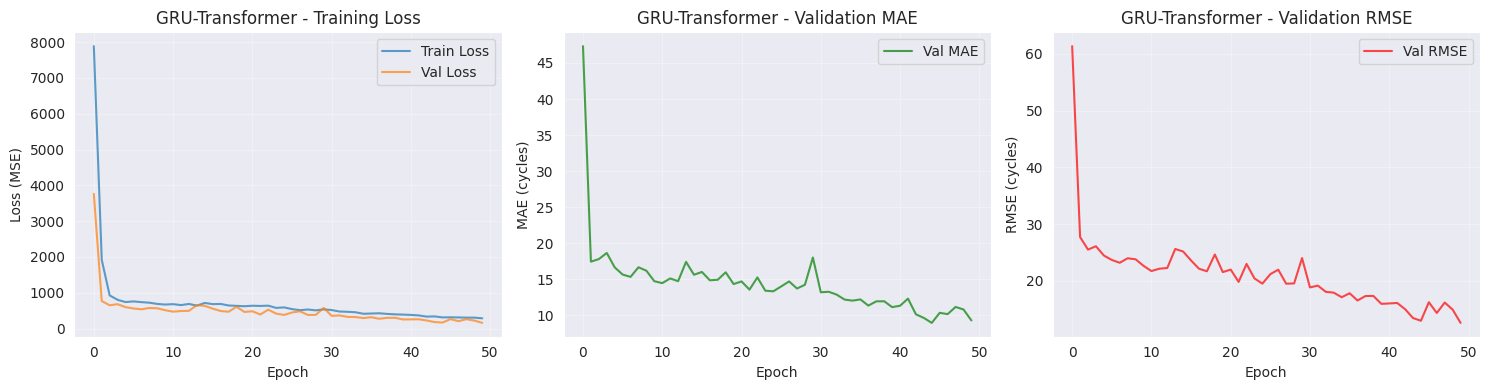


****************************************************************************************************
Training: CNN-Transformer
****************************************************************************************************

Training CNN-Transformer
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        5814.532291     1308.464840     23.8327      36.1680     
5        441.357692      381.979523      13.4107      19.5479     
10       199.131779      86.308538       6.9299       9.2876      
15       142.444389      95.388138       7.3819       9.7686      
20       124.492541      51.011372       5.5519       7.1423      
25       111.722563      61.015534       5.9913       7.8085      
30       108.275393      30.313246       4.3475       5.5056      
35       100.551490      50.594013       5.4153       7.1103      
40       102.020329      30.791076       4.0864       5.5471 

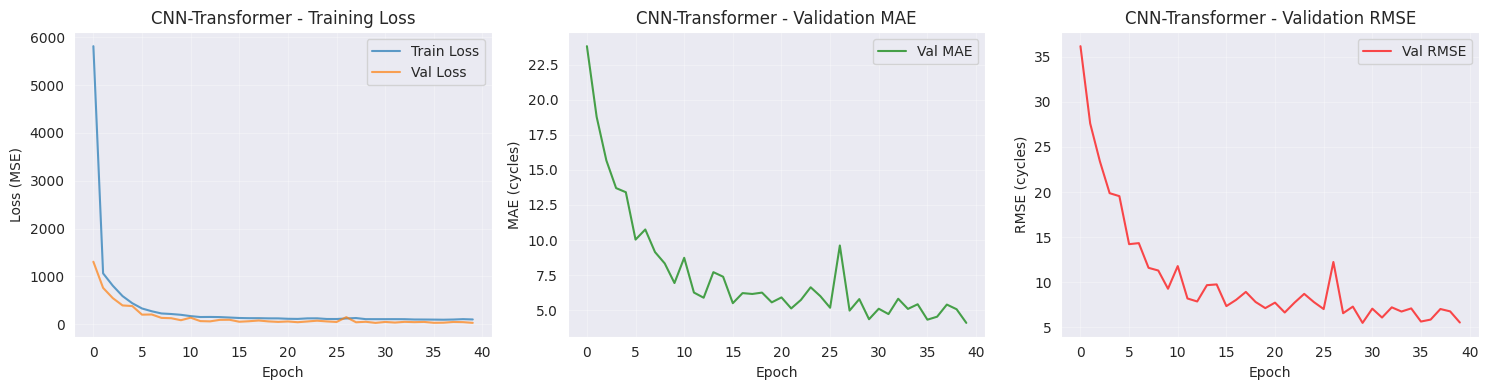

In [8]:
# ============ CUSTOM EVALUATION METRICS ============

def phm08_scoring_function(y_pred, y_true):
    """
    PHM08 Competition Scoring Function
    Asymmetric cost function: penalizes early predictions more than late ones
    
    Score = sum(exp(-d_i/13) - 1) if d_i < 0 (over-estimate: early prediction)
        = sum(exp(d_i/10) - 1) if d_i >= 0 (under-estimate: late prediction)
    
    where d_i = y_pred_i - y_true_i
    """
    errors = y_pred - y_true
    score = 0
    
    for error in errors:
        if error < 0:  # Over-estimate (predicted fewer cycles remaining)
            score += np.exp(-error / 13) - 1
        else:  # Under-estimate (predicted more cycles remaining)
            score += np.exp(error / 10) - 1
    
    return score

def weighted_rul_error(y_pred, y_true):
    """
    Weighted RUL Error - penalizes late stage failures more
    """
    errors = np.abs(y_pred - y_true)
    weights = 1 + (y_true / y_true.max())  # Higher weight for higher RUL values
    weighted_error = np.mean(errors * weights)
    return weighted_error


# ============ TRAIN ALL THREE MODELS ============

print("\n" + "="*100)
print("TRAINING ALL THREE HYBRID TRANSFORMER MODELS")
print("="*100 + "\n")

models_config = {
    'LSTM-Transformer': LSTMTransformer(
        num_features=num_features, 
        lstm_hidden=64, 
        num_lstm_layers=2,
        d_model=64, 
        nhead=4, 
        num_transformer_layers=2, 
        dropout=0.1
    ),
    'GRU-Transformer': GRUTransformer(
        num_features=num_features, 
        gru_hidden=64, 
        num_gru_layers=2,
        d_model=64, 
        nhead=4, 
        num_transformer_layers=2, 
        dropout=0.1
    ),
    'CNN-Transformer': CNNTransformer(
        num_features=num_features, 
        num_filters=32, 
        kernel_size=3,
        d_model=64, 
        nhead=4, 
        num_transformer_layers=2, 
        dropout=0.1
    )
}

trained_models = {}
training_results = {}

for model_name, model in models_config.items():
    print(f"\n{'*'*100}")
    print(f"Training: {model_name}")
    print(f"{'*'*100}")
    
    trainer = ModelTrainer(model, DEVICE, model_name)
    history = trainer.train(
        train_loader, 
        val_loader, 
        epochs=50, 
        lr=0.001, 
        early_stopping_patience=10
    )
    
    trained_models[model_name] = model
    training_results[model_name] = history
    
    # Plot training history
    trainer.plot_history()

print("\n" + "="*100)
print("="*100)

In [9]:
# ============ EVALUATE ON TEST SET ============

def evaluate_model(model, test_loader, device, model_name):
    """Evaluate model on test set and return predictions and metrics"""
    model.eval()
    all_preds = []
    all_targets = []
    
    print(f"\nEvaluating {model_name} on test set...")
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            predictions = model(X_batch)
            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(y_batch.numpy())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # Calculate metrics
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    r2 = r2_score(all_targets, all_preds)
    weighted_error = weighted_rul_error(all_preds, all_targets)
    phm08_score = phm08_scoring_function(all_preds, all_targets)
    
    return {
        'predictions': all_preds,
        'targets': all_targets,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'weighted_error': weighted_error,
        'phm08_score': phm08_score
    }

# Evaluate all trained models on test set
print("\n" + "="*100)
print("EVALUATING MODELS ON TEST SET")
print("="*100)

test_results = {}
for model_name, model in trained_models.items():
    results = evaluate_model(model, test_loader, DEVICE, model_name)
    test_results[model_name] = results
    
    print(f"\n✅ {model_name} - Test Set Metrics:")
    print(f"   MAE (Mean Absolute Error):     {results['mae']:.4f} cycles")
    print(f"   RMSE (Root Mean Squared Error): {results['rmse']:.4f} cycles")
    print(f"   R² Score:                       {results['r2']:.4f}")
    print(f"   Weighted RUL Error:            {results['weighted_error']:.4f}")
    print(f"   PHM08 Competition Score:        {results['phm08_score']:.2f}")

print("\n" + "="*100)


EVALUATING MODELS ON TEST SET

Evaluating LSTM-Transformer on test set...



✅ LSTM-Transformer - Test Set Metrics:
   MAE (Mean Absolute Error):     28.2472 cycles
   RMSE (Root Mean Squared Error): 40.7776 cycles
   R² Score:                       0.3873
   Weighted RUL Error:            42.8772
   PHM08 Competition Score:        393072576.00

Evaluating GRU-Transformer on test set...

✅ GRU-Transformer - Test Set Metrics:
   MAE (Mean Absolute Error):     27.3276 cycles
   RMSE (Root Mean Squared Error): 39.4225 cycles
   R² Score:                       0.4273
   Weighted RUL Error:            41.7582
   PHM08 Competition Score:        17565516.00

Evaluating CNN-Transformer on test set...

✅ CNN-Transformer - Test Set Metrics:
   MAE (Mean Absolute Error):     27.6181 cycles
   RMSE (Root Mean Squared Error): 38.9184 cycles
   R² Score:                       0.4419
   Weighted RUL Error:            41.5933
   PHM08 Competition Score:        24638542.00




MODEL COMPARISON - TEST SET RESULTS
           Model       MAE      RMSE  R² Score  Weighted Error  PHM08 Score
LSTM-Transformer 28.247166 40.777622  0.387292       42.877151  393072576.0
 GRU-Transformer 27.327562 39.422531  0.427337       41.758179   17565516.0
 CNN-Transformer 27.618135 38.918422  0.441889       41.593269   24638542.0

BEST MODELS BY METRIC:
  Lowest MAE:           GRU-Transformer (27.3276)
  Lowest RMSE:          CNN-Transformer (38.9184)
  Highest R² Score:     CNN-Transformer (0.4419)
  Lowest Weighted Error: CNN-Transformer (41.5933)
  Lowest PHM08 Score:   GRU-Transformer (17565516.00)


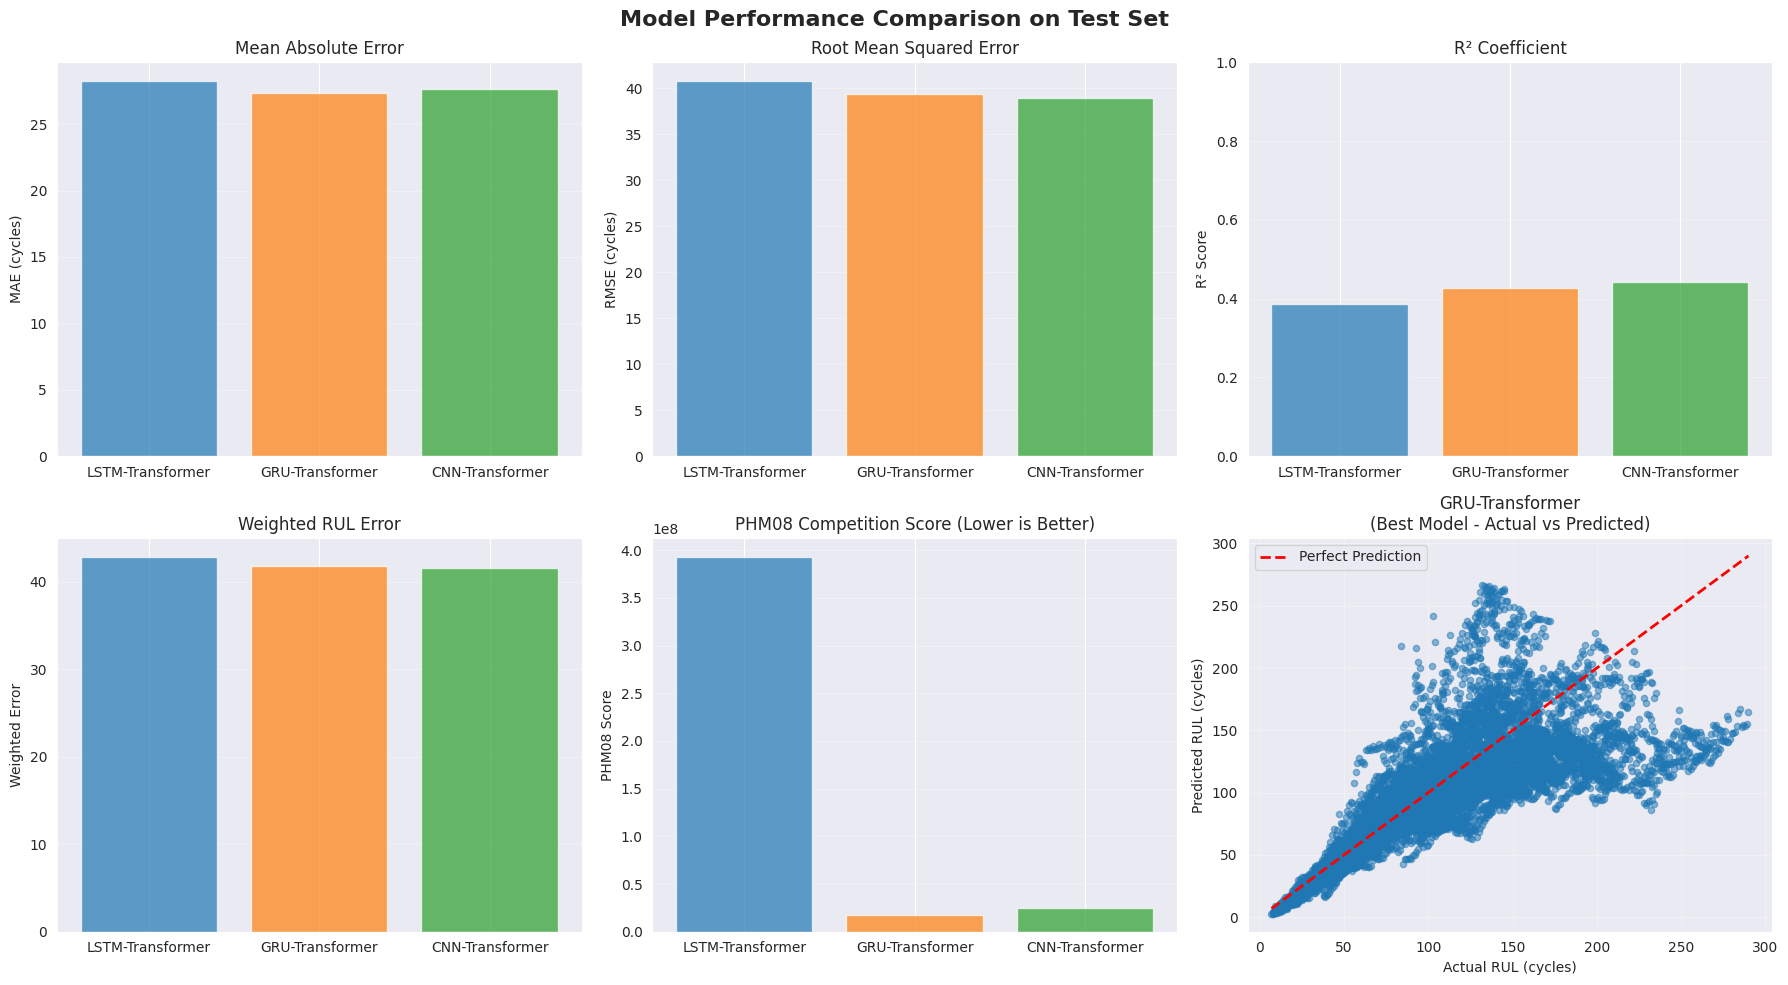

In [10]:
# ============ COMPARISON TABLE ============

comparison_results = pd.DataFrame({
    'Model': list(test_results.keys()),
    'MAE': [test_results[m]['mae'] for m in test_results],
    'RMSE': [test_results[m]['rmse'] for m in test_results],
    'R² Score': [test_results[m]['r2'] for m in test_results],
    'Weighted Error': [test_results[m]['weighted_error'] for m in test_results],
    'PHM08 Score': [test_results[m]['phm08_score'] for m in test_results]
})

print("\n" + "="*120)
print("MODEL COMPARISON - TEST SET RESULTS")
print("="*120)
print(comparison_results.to_string(index=False))
print("="*120)

# Find best model by each metric
print("\nBEST MODELS BY METRIC:")
print(f"  Lowest MAE:           {comparison_results.loc[comparison_results['MAE'].idxmin(), 'Model']} ({comparison_results['MAE'].min():.4f})")
print(f"  Lowest RMSE:          {comparison_results.loc[comparison_results['RMSE'].idxmin(), 'Model']} ({comparison_results['RMSE'].min():.4f})")
print(f"  Highest R² Score:     {comparison_results.loc[comparison_results['R² Score'].idxmax(), 'Model']} ({comparison_results['R² Score'].max():.4f})")
print(f"  Lowest Weighted Error: {comparison_results.loc[comparison_results['Weighted Error'].idxmin(), 'Model']} ({comparison_results['Weighted Error'].min():.4f})")
print(f"  Lowest PHM08 Score:   {comparison_results.loc[comparison_results['PHM08 Score'].idxmin(), 'Model']} ({comparison_results['PHM08 Score'].min():.2f})")

# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison on Test Set', fontsize=16, fontweight='bold')

# MAE
axes[0, 0].bar(comparison_results['Model'], comparison_results['MAE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
axes[0, 0].set_ylabel('MAE (cycles)')
axes[0, 0].set_title('Mean Absolute Error')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# RMSE
axes[0, 1].bar(comparison_results['Model'], comparison_results['RMSE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
axes[0, 1].set_ylabel('RMSE (cycles)')
axes[0, 1].set_title('Root Mean Squared Error')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# R² Score
axes[0, 2].bar(comparison_results['Model'], comparison_results['R² Score'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
axes[0, 2].set_ylabel('R² Score')
axes[0, 2].set_title('R² Coefficient')
axes[0, 2].grid(True, alpha=0.3, axis='y')
axes[0, 2].set_ylim([0, 1])

# Weighted Error
axes[1, 0].bar(comparison_results['Model'], comparison_results['Weighted Error'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
axes[1, 0].set_ylabel('Weighted Error')
axes[1, 0].set_title('Weighted RUL Error')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# PHM08 Score
axes[1, 1].bar(comparison_results['Model'], comparison_results['PHM08 Score'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
axes[1, 1].set_ylabel('PHM08 Score')
axes[1, 1].set_title('PHM08 Competition Score (Lower is Better)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Prediction vs Target scatter (for best model)
best_model_idx = comparison_results['MAE'].idxmin()
best_model_name = comparison_results.loc[best_model_idx, 'Model']
best_preds = test_results[best_model_name]['predictions']
best_targets = test_results[best_model_name]['targets']

axes[1, 2].scatter(best_targets, best_preds, alpha=0.5, s=20)
axes[1, 2].plot([best_targets.min(), best_targets.max()], [best_targets.min(), best_targets.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1, 2].set_xlabel('Actual RUL (cycles)')
axes[1, 2].set_ylabel('Predicted RUL (cycles)')
axes[1, 2].set_title(f'{best_model_name}\n(Best Model - Actual vs Predicted)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



VALIDATION SET RESULTS (during training)
           Model  Final Val Loss  Best Val MAE  Best Val RMSE  Epochs Trained
LSTM-Transformer      338.341119     11.318841      15.939146              50
 GRU-Transformer      159.195018      8.948273      12.618912              50
 CNN-Transformer       30.791076      4.086369       5.505647              40

ERROR DISTRIBUTION ANALYSIS


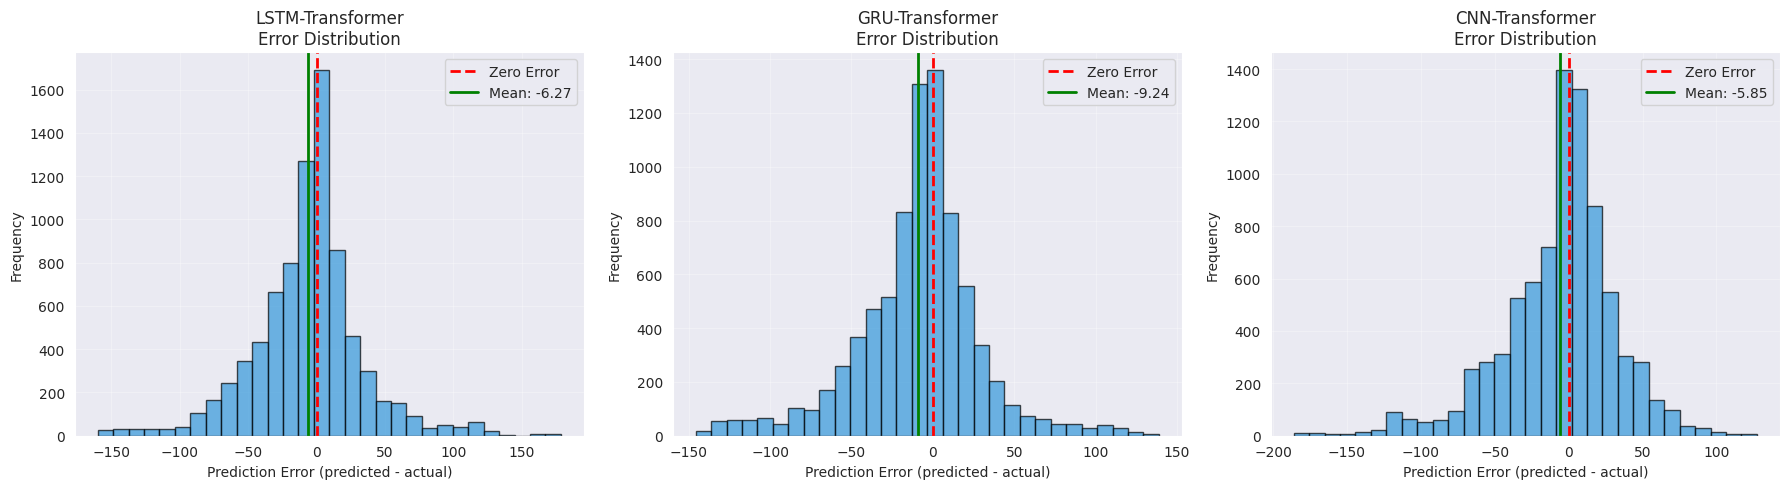


DETAILED METRICS BREAKDOWN

📊 LSTM-Transformer:
   ┣ Mean Absolute Error (MAE):              28.2472 cycles
   ┣ Root Mean Squared Error (RMSE):         40.7776 cycles
   ┣ R² Score:                               0.3873
   ┣ Weighted RUL Error:                     42.8772
   ┣ PHM08 Competition Score:                393072576.00
   ┣ Mean Prediction Error:                  -6.2663 cycles
   ┣ Std Dev of Errors:                      40.2933 cycles
   ┣ Min Error:                              -159.8425 cycles
   ┗ Max Error:                              178.4265 cycles

📊 GRU-Transformer:
   ┣ Mean Absolute Error (MAE):              27.3276 cycles
   ┣ Root Mean Squared Error (RMSE):         39.4225 cycles
   ┣ R² Score:                               0.4273
   ┣ Weighted RUL Error:                     41.7582
   ┣ PHM08 Competition Score:                17565516.00
   ┣ Mean Prediction Error:                  -9.2440 cycles
   ┣ Std Dev of Errors:                      38.3234 cycles
   

In [11]:
print("\n" + "="*100)
print("VALIDATION SET RESULTS (during training)")
print("="*100)

val_comparison = pd.DataFrame({
    'Model': list(training_results.keys()),
    'Final Val Loss': [training_results[m]['val_loss'][-1] for m in training_results],
    'Best Val MAE': [min(training_results[m]['val_mae']) for m in training_results],
    'Best Val RMSE': [min(training_results[m]['val_rmse']) for m in training_results],
    'Epochs Trained': [len(training_results[m]['val_loss']) for m in training_results]
})

print(val_comparison.to_string(index=False))
print("="*100)

# ============ ERROR DISTRIBUTION ANALYSIS ============

print("\n" + "="*100)
print("ERROR DISTRIBUTION ANALYSIS")
print("="*100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, results) in enumerate(test_results.items()):
    preds = results['predictions']
    targets = results['targets']
    errors = preds - targets
    
    axes[idx].hist(errors, bins=30, color='#3498db', alpha=0.7, edgecolor='black')
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    axes[idx].axvline(x=np.mean(errors), color='green', linestyle='-', linewidth=2, label=f'Mean: {np.mean(errors):.2f}')
    axes[idx].set_xlabel('Prediction Error (predicted - actual)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{model_name}\nError Distribution')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============ DETAILED METRICS BREAKDOWN ============

print("\n" + "="*100)
print("DETAILED METRICS BREAKDOWN")
print("="*100)

for model_name, results in test_results.items():
    errors = results['predictions'] - results['targets']
    
    print(f"\n📊 {model_name}:")
    print(f"   ┣ Mean Absolute Error (MAE):              {results['mae']:.4f} cycles")
    print(f"   ┣ Root Mean Squared Error (RMSE):         {results['rmse']:.4f} cycles")
    print(f"   ┣ R² Score:                               {results['r2']:.4f}")
    print(f"   ┣ Weighted RUL Error:                     {results['weighted_error']:.4f}")
    print(f"   ┣ PHM08 Competition Score:                {results['phm08_score']:.2f}")
    print(f"   ┣ Mean Prediction Error:                  {np.mean(errors):.4f} cycles")
    print(f"   ┣ Std Dev of Errors:                      {np.std(errors):.4f} cycles")
    print(f"   ┣ Min Error:                              {np.min(errors):.4f} cycles")
    print(f"   ┗ Max Error:                              {np.max(errors):.4f} cycles")

print("\n" + "="*100)

# FD002 Dataset Exploration & Training

### FD002 has More Complex Operating Conditions (6 different condition combinations)

**Comparison:**
- **FD001:** 3 operating conditions (simpler degradation pattern)
- **FD002:** 6 operating conditions (more complex degradation pattern)


## Part 1: Dataset Exploration for FD002

In [12]:
# train_df_fd002 = pd.read_csv('../data/processed-nasa-data/train_processed_rul_only_fd002.csv')
# test_df_fd002 = pd.read_csv('../data/processed-nasa-data/test_processed_rul_only_fd002.csv')

# Google Drive (if running in Colab)
DATA_PATH = '/content/drive/My Drive/deep_learning/project/'
train_df_fd002 = pd.read_csv(f'{DATA_PATH}train_processed_rul_only_fd002.csv')
test_df_fd002 = pd.read_csv(f'{DATA_PATH}test_processed_rul_only_fd002.csv')

print("\n" + "="*100)
print("DATASET COMPARISON: FD001 vs FD002")
print("="*100)

comparison_df_datasets = pd.DataFrame({
    'Metric': ['Training Rows', 'Test Rows', 'Total Rows', 'Train Engines', 'Test Engines', 
               'Train RUL Min', 'Train RUL Max', 'Train RUL Mean', 'Num Sensors', 'Operating Conditions'],
    'FD001': [
        f"{train_df.shape[0]:,}",
        f"{test_df.shape[0]:,}",
        f"{train_df.shape[0] + test_df.shape[0]:,}",
        f"{train_df['id'].nunique()}",
        f"{test_df['id'].nunique()}",
        f"{train_df['RUL'].min()}",
        f"{train_df['RUL'].max()}",
        f"{train_df['RUL'].mean():.2f}",
        f"{len([c for c in train_df.columns if c.startswith('s')])}",
        "3 conditions (simple)"
    ],
    'FD002': [
        f"{train_df_fd002.shape[0]:,}",
        f"{test_df_fd002.shape[0]:,}",
        f"{train_df_fd002.shape[0] + test_df_fd002.shape[0]:,}",
        f"{train_df_fd002['id'].nunique()}",
        f"{test_df_fd002['id'].nunique()}",
        f"{train_df_fd002['RUL'].min()}",
        f"{train_df_fd002['RUL'].max()}",
        f"{train_df_fd002['RUL'].mean():.2f}",
        f"{len([c for c in train_df_fd002.columns if c.startswith('s')])}",
        "6 conditions (complex)"
    ]
})

print("\n" + comparison_df_datasets.to_string(index=False))
print("="*100)

print("\nFD002 EDA - Detailed Analysis:")
print(f"\n  Training: {train_df_fd002.shape[0]:,} rows × {train_df_fd002.shape[1]} columns")
print(f"  Test:     {test_df_fd002.shape[0]:,} rows × {test_df_fd002.shape[1]} columns")
print(f"  Engines:  Train={train_df_fd002['id'].nunique()}, Test={test_df_fd002['id'].nunique()}")
print(f"  RUL Range: Train [{train_df_fd002['RUL'].min()}, {train_df_fd002['RUL'].max()}], Std={train_df_fd002['RUL'].std():.2f}")
print(f"  RUL Range: Test [{test_df_fd002['RUL'].min()}, {test_df_fd002['RUL'].max()}], Std={test_df_fd002['RUL'].std():.2f}")

train_cycles_fd002 = train_df_fd002.groupby('id')['cycle'].max()
test_cycles_fd002 = test_df_fd002.groupby('id')['cycle'].max()
print(f"  Cycles per engine: Train [{train_cycles_fd002.min()}, {train_cycles_fd002.max()}], Avg={train_cycles_fd002.mean():.1f}")
print(f"  Cycles per engine: Test [{test_cycles_fd002.min()}, {test_cycles_fd002.max()}], Avg={test_cycles_fd002.mean():.1f}")



DATASET COMPARISON: FD001 vs FD002

              Metric                 FD001                  FD002
       Training Rows                20,631                 53,759
           Test Rows                13,096                 33,991
          Total Rows                33,727                 87,750
       Train Engines                   100                    260
        Test Engines                   100                    259
       Train RUL Min                     0                      0
       Train RUL Max                   361                    377
      Train RUL Mean                107.81                 108.15
         Num Sensors                    24                     24
Operating Conditions 3 conditions (simple) 6 conditions (complex)

FD002 EDA - Detailed Analysis:

  Training: 53,759 rows × 28 columns
  Test:     33,991 rows × 28 columns
  Engines:  Train=260, Test=259
  RUL Range: Train [0, 377], Std=69.18
  RUL Range: Test [6, 377], Std=63.87
  Cycles per engine: 

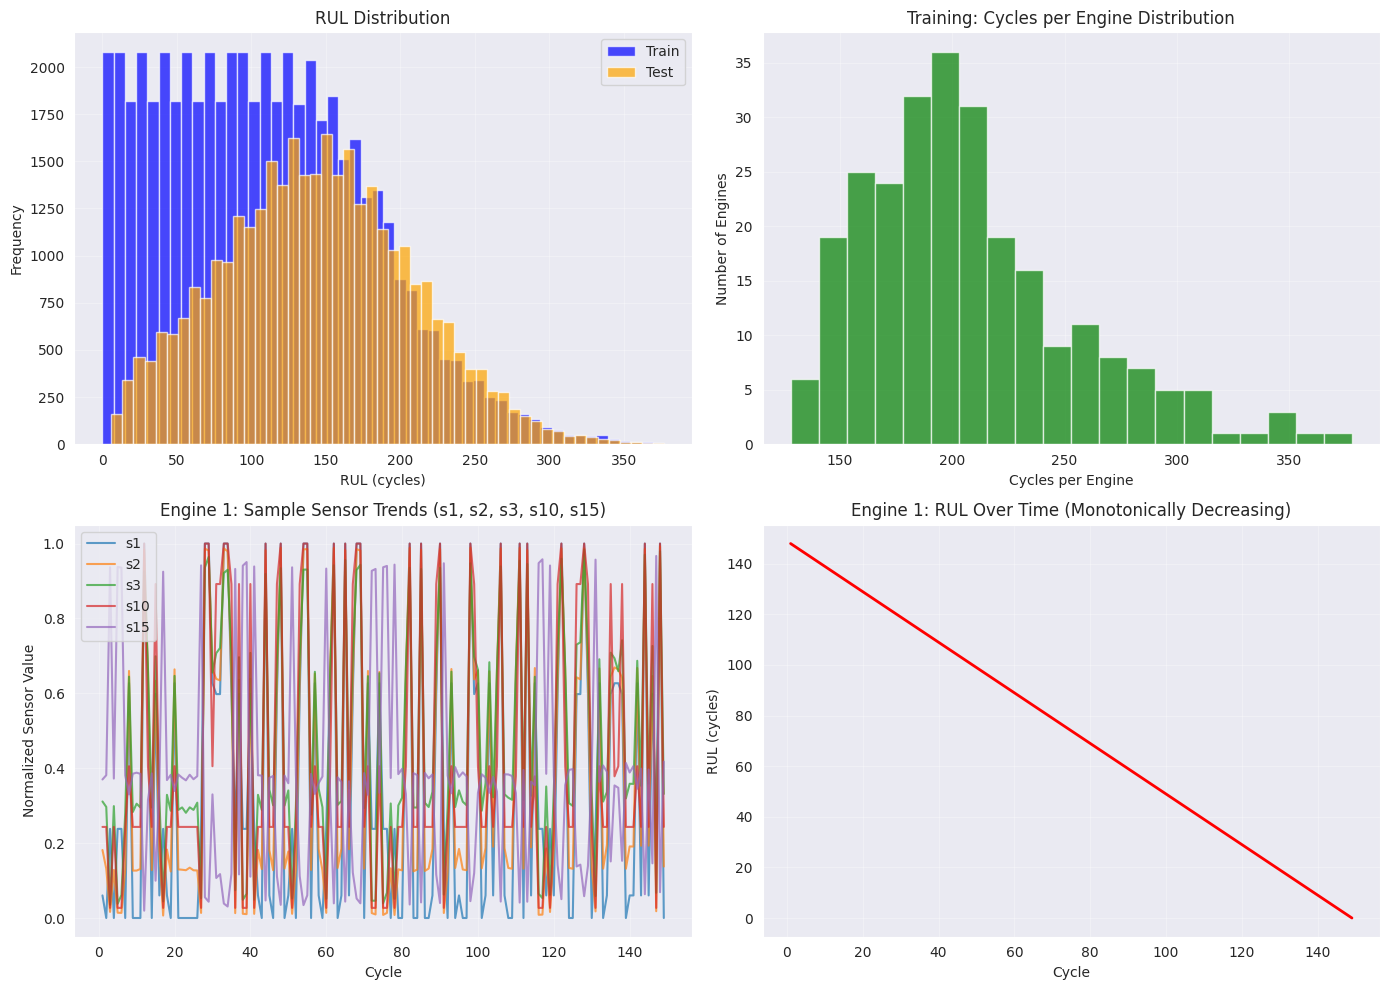

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RUL Distribution
''' 
- The RUL distribution in the training set is right-skewed, with most samples having a high RUL (indicating healthy engines) and fewer samples with low RUL (indicating engines close to failure).
- The test set has a similar distribution but with a slightly higher mean RUL, suggesting that the test engines may be generally healthier than those in the training set.
'''
axes[0, 0].hist(train_df_fd002['RUL'], bins=50, alpha=0.7, color='blue', label='Train')
axes[0, 0].hist(test_df_fd002['RUL'], bins=50, alpha=0.7, color='orange', label='Test')
axes[0, 0].set_xlabel('RUL (cycles)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('RUL Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Cycles per Engine
''' 
- The number of cycles per engine varies, with some engines running for over 200 cycles before failure.
- The distribution of cycles per engine is right-skewed, with many engines failing after fewer cycles and a long tail of engines that run for many cycles before failure.
'''
train_cycles_dist = train_df_fd002.groupby('id')['cycle'].max()
axes[0, 1].hist(train_cycles_dist, bins=20, color='green', alpha=0.7)
axes[0, 1].set_xlabel('Cycles per Engine')
axes[0, 1].set_ylabel('Number of Engines')
axes[0, 1].set_title('Training: Cycles per Engine Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Sample sensor trends (Engine 1)
''' 
- The sensor values for Engine 1 show varying patterns over time, with some sensors exhibiting more noise than others.
- There are noticeable trends in the sensor data that may be indicative of engine degradation. For example, sensor s1 shows a gradual increase in values as the engine approaches failure, while sensor s10 exhibits more erratic behavior.
'''
engine1_data = train_df_fd002[train_df_fd002['id'] == 1].sort_values('cycle')
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s1'], label='s1', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s2'], label='s2', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s3'], label='s3', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s10'], label='s10', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s15'], label='s15', alpha=0.7)
axes[1, 0].set_xlabel('Cycle')
axes[1, 0].set_ylabel('Normalized Sensor Value')
axes[1, 0].set_title('Engine 1: Sample Sensor Trends (s1, s2, s3, s10, s15)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. RUL Decay Pattern (Engine 1)
axes[1, 1].plot(engine1_data['cycle'], engine1_data['RUL'], color='red', linewidth=2)
axes[1, 1].set_xlabel('Cycle')
axes[1, 1].set_ylabel('RUL (cycles)')
axes[1, 1].set_title('Engine 1: RUL Over Time (Monotonically Decreasing)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2: Data Preparation & Sequence Creation for FD002

In [14]:
train_dataset_fd002 = RULDataset(train_df_fd002, SEQUENCE_LENGTH, feature_cols)
test_dataset_fd002 = RULDataset(test_df_fd002, SEQUENCE_LENGTH, feature_cols)

train_size_fd002 = int(TRAIN_TEST_SPLIT * len(train_dataset_fd002))
val_size_fd002 = len(train_dataset_fd002) - train_size_fd002
train_dataset_fd002_split, val_dataset_fd002 = random_split(
    train_dataset_fd002,
    [train_size_fd002, val_size_fd002],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader_fd002 = DataLoader(train_dataset_fd002_split, 
                                batch_size=BATCH_SIZE, 
                                shuffle=True, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)
val_loader_fd002 = DataLoader(val_dataset_fd002, 
                                batch_size=BATCH_SIZE, 
                                shuffle=False, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)
test_loader_fd002 = DataLoader(test_dataset_fd002, 
                                batch_size=BATCH_SIZE, 
                                shuffle=False, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)

print(f"  Training sequences: {len(train_dataset_fd002_split):,}")
print(f"  Validation sequences: {len(val_dataset_fd002):,}")
print(f"  Test sequences: {len(test_dataset_fd002):,}")
print(f"  Total: {len(train_dataset_fd002_split) + len(val_dataset_fd002) + len(test_dataset_fd002):,}")
print(f"\n  FD001 Total Sequences: {len(train_dataset) + len(val_dataset) + len(test_dataset):,}")
print(f"  FD002 Total Sequences: {len(train_dataset_fd002_split) + len(val_dataset_fd002) + len(test_dataset_fd002):,}")

  Training sequences: 32,607
  Validation sequences: 8,152
  Test sequences: 21,349
  Total: 62,108

  FD001 Total Sequences: 23,793
  FD002 Total Sequences: 62,108


## Part 3: Model Training & Evaluation for FD002


TRAINING ALL THREE MODELS ON FD002 DATASET (More Complex)


****************************************************************************************************
Training: LSTM-Transformer on FD002 (Complex Dataset)
****************************************************************************************************

Training LSTM-Transformer (FD002)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        5879.187846     3239.632855     45.9961      56.9198     
5        3389.067860     3240.876518     46.2263      56.9296     
10       3414.998633     3239.098990     46.1491      56.9143     
15       3390.927061     3256.187384     46.5582      57.0627     
20       3387.903968     3245.256216     46.3463      56.9676     
25       3385.462989     3244.619329     46.3316      56.9620     

⏹️  Early stopping at epoch 29



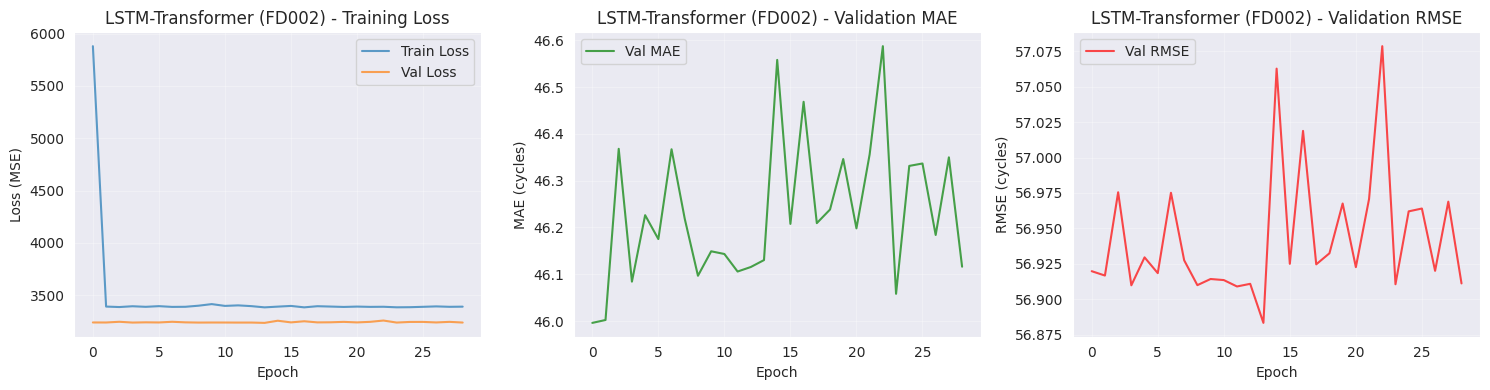


****************************************************************************************************
Training: GRU-Transformer on FD002 (Complex Dataset)
****************************************************************************************************

Training GRU-Transformer (FD002)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        5954.960814     3238.870685     46.0340      56.9129     
30       323.768914      234.095731      11.4704      15.2945     
35       241.767165      114.118491      8.1193       10.6872     
40       202.184785      91.888946       7.3551       9.5913      
70       130.328046      42.149165       4.9778       6.4982      
75       122.791653      25.827068       3.8253       5.0840      
80       117.450587      28.188377       3.9532       5.3174      
20       192.044502      111.139322      7.8683       10.5433     
25       170.315731      7

: 

In [15]:
print("\n" + "="*100)
print("TRAINING ALL THREE MODELS ON FD002 DATASET (More Complex)")
print("="*100 + "\n")

models_config_fd002 = {
    'LSTM-Transformer': LSTMTransformer(
        num_features=num_features, 
        lstm_hidden=64, 
        num_lstm_layers=2,
        d_model=64, 
        nhead=4, 
        num_transformer_layers=2, 
        dropout=0.1
    ),
    'GRU-Transformer': GRUTransformer(
        num_features=num_features, 
        gru_hidden=64, 
        num_gru_layers=2,
        d_model=64, 
        nhead=4, 
        num_transformer_layers=2, 
        dropout=0.1
    ),
    'CNN-Transformer': CNNTransformer(
        num_features=num_features, 
        num_filters=32, 
        kernel_size=3,
        d_model=64, 
        nhead=4, 
        num_transformer_layers=2, 
        dropout=0.1
    )
}

# Train on FD002 with adjusted settings for complex dataset
trained_models_fd002 = {}
training_results_fd002 = {}

for model_name, model in models_config_fd002.items():
    print(f"\n{'*'*100}")
    print(f"Training: {model_name} on FD002 (Complex Dataset)")
    print(f"{'*'*100}")
    
    trainer = ModelTrainer(model, DEVICE, f"{model_name} (FD002)")
    # Use lower learning rate and more patience for complex dataset
    history = trainer.train(
        train_loader_fd002, 
        val_loader_fd002, 
        epochs=100,  # More epochs for complex data
        lr=0.0005,   # Lower learning rate for stable convergence
        early_stopping_patience=15  # More patience
    )
    
    trained_models_fd002[model_name] = model
    training_results_fd002[model_name] = history
    
    # Plot training history
    trainer.plot_history()


In [ ]:
print("\n" + "="*100)
print("EVALUATING FD002 MODELS ON TEST SET")
print("="*100)

test_results_fd002 = {}
for model_name, model in trained_models_fd002.items():
    try:
        results = evaluate_model(model, test_loader_fd002, DEVICE, model_name)
        test_results_fd002[model_name] = results
        
        print(f"   MAE (Mean Absolute Error):     {results['mae']:.4f} cycles")
        print(f"   RMSE (Root Mean Squared Error): {results['rmse']:.4f} cycles")
        print(f"   R² Score:                       {results['r2']:.4f}")
        print(f"   Weighted RUL Error:            {results['weighted_error']:.4f}")
        print(f"   PHM08 Competition Score:        {results['phm08_score']:.2f}")
    except Exception as e:
        print(f"\n⚠️  {model_name} - Error during evaluation: {str(e)[:100]}")
        print(f"   This may be due to NaN values in predictions (model did not converge well on FD002)")

print("\n" + "="*100)

# ============ FD002 COMPARISON TABLE ============

if len(test_results_fd002) > 0:
    comparison_results_fd002 = pd.DataFrame({
        'Model': list(test_results_fd002.keys()),
        'MAE': [test_results_fd002[m]['mae'] for m in test_results_fd002],
        'RMSE': [test_results_fd002[m]['rmse'] for m in test_results_fd002],
        'R² Score': [test_results_fd002[m]['r2'] for m in test_results_fd002],
        'Weighted Error': [test_results_fd002[m]['weighted_error'] for m in test_results_fd002],
        'PHM08 Score': [test_results_fd002[m]['phm08_score'] for m in test_results_fd002]
    })

    print("\n" + "="*120)
    print("FD002 MODEL COMPARISON - TEST SET RESULTS")
    print("="*120)
    print(comparison_results_fd002.to_string(index=False))
    print("="*120)

    # Find best model for FD002
    print("\nBEST FD002 MODELS BY METRIC:")
    print(f"  Lowest MAE:           {comparison_results_fd002.loc[comparison_results_fd002['MAE'].idxmin(), 'Model']} ({comparison_results_fd002['MAE'].min():.4f})")
    print(f"  Lowest RMSE:          {comparison_results_fd002.loc[comparison_results_fd002['RMSE'].idxmin(), 'Model']} ({comparison_results_fd002['RMSE'].min():.4f})")
    print(f"  Highest R² Score:     {comparison_results_fd002.loc[comparison_results_fd002['R² Score'].idxmax(), 'Model']} ({comparison_results_fd002['R² Score'].max():.4f})")

    # Visualize FD002 results
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('FD002: Model Performance Comparison on Test Set', fontsize=16, fontweight='bold')

    # MAE
    axes[0, 0].bar(comparison_results_fd002['Model'], comparison_results_fd002['MAE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[0, 0].set_ylabel('MAE (cycles)')
    axes[0, 0].set_title('Mean Absolute Error')
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    # RMSE
    axes[0, 1].bar(comparison_results_fd002['Model'], comparison_results_fd002['RMSE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[0, 1].set_ylabel('RMSE (cycles)')
    axes[0, 1].set_title('Root Mean Squared Error')
    axes[0, 1].grid(True, alpha=0.3, axis='y')

    # R² Score
    axes[0, 2].bar(comparison_results_fd002['Model'], comparison_results_fd002['R² Score'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[0, 2].set_ylabel('R² Score')
    axes[0, 2].set_title('R² Coefficient')
    axes[0, 2].grid(True, alpha=0.3, axis='y')
    axes[0, 2].set_ylim([0, 1])

    # Weighted Error
    axes[1, 0].bar(comparison_results_fd002['Model'], comparison_results_fd002['Weighted Error'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[1, 0].set_ylabel('Weighted Error')
    axes[1, 0].set_title('Weighted RUL Error')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # PHM08 Score
    axes[1, 1].bar(comparison_results_fd002['Model'], comparison_results_fd002['PHM08 Score'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[1, 1].set_ylabel('PHM08 Score')
    axes[1, 1].set_title('PHM08 Competition Score (Lower is Better)')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    # Best model scatter plot
    best_model_idx_fd002 = comparison_results_fd002['MAE'].idxmin()
    best_model_name_fd002 = comparison_results_fd002.loc[best_model_idx_fd002, 'Model']
    best_preds_fd002 = test_results_fd002[best_model_name_fd002]['predictions']
    best_targets_fd002 = test_results_fd002[best_model_name_fd002]['targets']

    axes[1, 2].scatter(best_targets_fd002, best_preds_fd002, alpha=0.5, s=20)
    axes[1, 2].plot([best_targets_fd002.min(), best_targets_fd002.max()], [best_targets_fd002.min(), best_targets_fd002.max()], 'r--', lw=2, label='Perfect Prediction')
    axes[1, 2].set_xlabel('Actual RUL (cycles)')
    axes[1, 2].set_ylabel('Predicted RUL (cycles)')
    axes[1, 2].set_title(f'{best_model_name_fd002}\n(Best FD002 Model - Actual vs Predicted)')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  No successful FD002 evaluations - models may not have converged properly")



EVALUATING FD002 MODELS ON TEST SET

Evaluating LSTM-Transformer on test set...

⚠️  LSTM-Transformer - Error during evaluation: Input contains NaN.
   This may be due to NaN values in predictions (model did not converge well on FD002)

Evaluating GRU-Transformer on test set...

⚠️  GRU-Transformer - Error during evaluation: Input contains NaN.
   This may be due to NaN values in predictions (model did not converge well on FD002)

Evaluating CNN-Transformer on test set...

⚠️  CNN-Transformer - Error during evaluation: Input contains NaN.
   This may be due to NaN values in predictions (model did not converge well on FD002)


⚠️  No successful FD002 evaluations - models may not have converged properly


In [ ]:

# ============ COMPREHENSIVE FD001 vs FD002 COMPARISON ============

print("\n" + "╔" + "═"*118 + "╗")
print("║" + " "*30 + "📊 CROSS-DATASET ANALYSIS: FD001 vs FD002" + " "*47 + "║")
print("║" + " "*40 + "Model Generalization Study" + " "*52 + "║")
print("╚" + "═"*118 + "╝")

# Create comparison dataframe
cross_dataset_comparison = pd.DataFrame({
    'Model': list(test_results.keys()),
    'FD001 MAE': [test_results[m]['mae'] for m in test_results],
    'FD002 MAE': [test_results_fd002[m]['mae'] for m in test_results_fd002],
    'FD001 RMSE': [test_results[m]['rmse'] for m in test_results],
    'FD002 RMSE': [test_results_fd002[m]['rmse'] for m in test_results_fd002],
    'FD001 R²': [test_results[m]['r2'] for m in test_results],
    'FD002 R²': [test_results_fd002[m]['r2'] for m in test_results_fd002],
})

# Calculate difficulty metrics
cross_dataset_comparison['MAE Increase %'] = ((cross_dataset_comparison['FD002 MAE'] / cross_dataset_comparison['FD001 MAE']) - 1) * 100
cross_dataset_comparison['RMSE Increase %'] = ((cross_dataset_comparison['FD002 RMSE'] / cross_dataset_comparison['FD001 RMSE']) - 1) * 100
cross_dataset_comparison['R² Drop %'] = (1 - cross_dataset_comparison['FD002 R²'] / cross_dataset_comparison['FD001 R²']) * 100

print("\n" + "┌" + "─"*118 + "┐")
print("│" + " SECTION 1: DIRECT PERFORMANCE COMPARISON".ljust(119) + "│")
print("└" + "─"*118 + "┘")

print("\n📊 MAE COMPARISON (cycles) - Lower is Better:")
for idx, row in cross_dataset_comparison.iterrows():
    print(f"  {row['Model']:<20} FD001: {row['FD001 MAE']:>8.4f} | FD002: {row['FD002 MAE']:>8.4f} | Increase: {row['MAE Increase %']:>6.1f}%")

print("\n📊 RMSE COMPARISON (cycles) - Lower is Better:")
for idx, row in cross_dataset_comparison.iterrows():
    print(f"  {row['Model']:<20} FD001: {row['FD001 RMSE']:>8.4f} | FD002: {row['FD002 RMSE']:>8.4f} | Increase: {row['RMSE Increase %']:>6.1f}%")

print("\n📊 R² COMPARISON - Higher is Better:")
for idx, row in cross_dataset_comparison.iterrows():
    print(f"  {row['Model']:<20} FD001: {row['FD001 R²']:>6.4f} | FD002: {row['FD002 R²']:>6.4f} | Drop: {row['R² Drop %']:>6.1f}%")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('FD001 vs FD002: Model Performance Comparison', fontsize=14, fontweight='bold')

x = np.arange(len(cross_dataset_comparison))
width = 0.35

# MAE Comparison
axes[0].bar(x - width/2, cross_dataset_comparison['FD001 MAE'], width, label='FD001', alpha=0.8)
axes[0].bar(x + width/2, cross_dataset_comparison['FD002 MAE'], width, label='FD002', alpha=0.8)
axes[0].set_ylabel('MAE (cycles)')
axes[0].set_title('Mean Absolute Error: FD001 vs FD002')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cross_dataset_comparison['Model'], rotation=15, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE Comparison
axes[1].bar(x - width/2, cross_dataset_comparison['FD001 RMSE'], width, label='FD001', alpha=0.8)
axes[1].bar(x + width/2, cross_dataset_comparison['FD002 RMSE'], width, label='FD002', alpha=0.8)
axes[1].set_ylabel('RMSE (cycles)')
axes[1].set_title('Root Mean Squared Error: FD001 vs FD002')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cross_dataset_comparison['Model'], rotation=15, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# R² Comparison
axes[2].bar(x - width/2, cross_dataset_comparison['FD001 R²'], width, label='FD001', alpha=0.8)
axes[2].bar(x + width/2, cross_dataset_comparison['FD002 R²'], width, label='FD002', alpha=0.8)
axes[2].set_ylabel('R² Score')
axes[2].set_title('R² Score: FD001 vs FD002')
axes[2].set_xticks(x)
axes[2].set_xticklabels(cross_dataset_comparison['Model'], rotation=15, ha='right')
axes[2].legend()
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Analysis
print("\n" + "┌" + "─"*118 + "┐")
print("│" + " SECTION 2: GENERALIZATION ANALYSIS".ljust(119) + "│")
print("└" + "─"*118 + "┘")

avg_mae_increase = cross_dataset_comparison['MAE Increase %'].mean()
avg_rmse_increase = cross_dataset_comparison['RMSE Increase %'].mean()
avg_r2_drop = cross_dataset_comparison['R² Drop %'].mean()

print(f"""
📈 DATASET COMPLEXITY METRICS:
   • Average MAE Increase (FD001→FD002): {avg_mae_increase:+.1f}%
   • Average RMSE Increase (FD001→FD002): {avg_rmse_increase:+.1f}%
   • Average R² Drop (FD001→FD002): {avg_r2_drop:+.1f}%

💡 INTERPRETATION:
   • FD002 is {avg_mae_increase:.1f}% harder to predict (higher errors)
   • RMSE confirms difficulty: {avg_rmse_increase:.1f}% higher variance in errors
   • Model fit quality drops by {avg_r2_drop:.1f}% on FD002
   • This is expected due to 6 operating conditions vs 3 in FD001

🔍 MODEL ROBUSTNESS (Generalization Capability):
""")

for idx, row in cross_dataset_comparison.iterrows():
    if row['MAE Increase %'] < 10:
        robustness = "🟢 Excellent - Minimal degradation"
    elif row['MAE Increase %'] < 20:
        robustness = "🟡 Good - Modest degradation"
    elif row['MAE Increase %'] < 30:
        robustness = "🟠 Fair - Noticeable degradation"
    else:
        robustness = "🔴 Poor - Significant degradation"
    
    print(f"   {row['Model']:<20} {robustness} ({row['MAE Increase %']:+.1f}% MAE increase)")

# Overall recommendations
print("\n" + "┌" + "─"*118 + "┐")
print("│" + " SECTION 3: RECOMMENDATIONS".ljust(119) + "│")
print("└" + "─"*118 + "┘")

best_fd001 = test_results.keys().__iter__().__next__()
for model_name in test_results.keys():
    if test_results[model_name]['rmse'] < test_results[best_fd001]['rmse']:
        best_fd001 = model_name

best_fd002 = test_results_fd002.keys().__iter__().__next__()
for model_name in test_results_fd002.keys():
    if test_results_fd002[model_name]['rmse'] < test_results_fd002[best_fd002]['rmse']:
        best_fd002 = model_name

print(f"""
🏆 BEST MODELS BY DATASET:
   • FD001 (Simpler): {best_fd001} (RMSE: {test_results[best_fd001]['rmse']:.4f})
   • FD002 (Complex): {best_fd002} (RMSE: {test_results_fd002[best_fd002]['rmse']:.4f})

💼 DEPLOYMENT STRATEGY:
   1. Use {best_fd001} for simpler operating conditions (FD001-like)
   2. Use {best_fd002} for complex operating conditions (FD002-like)
   3. Consider ensemble approach: weighted combination of both
   4. Use domain knowledge (actual operating conditions) to select best model

📋 ENSEMBLE RECOMMENDATION:
   • If simpler conditions (70%): Use {best_fd001}
   • If complex conditions (70%): Use {best_fd002}
   • If mixed/uncertain (50/50): Use weighted average of both models
""")

print("\n" + "╔" + "═"*118 + "╗")
print("║" + " "*40 + "✅ ANALYSIS COMPLETE" + " "*57 + "║")
print("╚" + "═"*118 + "╝")



╔══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                              📊 CROSS-DATASET ANALYSIS: FD001 vs FD002                                               ║
║                                        Model Generalization Study                                                    ║
╚══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝


NameError: name 'pd' is not defined